In [ ]:
from viewer.utils import load_env
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmap

colormap = cmap.Colormap('tab20').to_matplotlib()
ks_output = Path(load_env('.env')["EPHYS_DATA_PATH"]) / "kilosort"

In [38]:
# LOAD PROBE CONTACTS 
ch_pos = np.load(ks_output / 'channel_positions.npy')
ch_shanks = np.load(ks_output / 'channel_shanks.npy').astype(int)
contacts_df = pd.DataFrame(ch_pos, columns=['x', 'y'])
contacts_df['shank'] = ch_shanks.astype(int)

# LOAD UNITS FROM KILOSORT OUTPUT
unit_labels = pd.read_csv(ks_output / 'cluster_group.tsv', sep='\t', index_col=0)
good_units = unit_labels[unit_labels['group'] == 'good'].index.values

clu = np.load(ks_output / 'spike_clusters.npy', mmap_mode='r')
spike_locations = np.load(ks_output / 'spike_positions.npy', mmap_mode='r')

good_mask = np.isin(clu, good_units)
spikes_df = pd.DataFrame(spike_locations[good_mask], columns=['x', 'y'])
spikes_df['cluster'] = clu[good_mask]
units_df = spikes_df.groupby('cluster').agg(['mean'])
units_df.columns = ['_'.join(col) for col in units_df.columns]

In [39]:
units_df

,x_mean,y_mean
cluster,,
18,12.412506,1007.089417
23,21.383923,1052.564941
26,13.031116,1065.637207
29,12.312404,1063.863647
32,11.823097,1076.413086
...,...,...
1063,261.985260,1021.237549
1064,265.271637,1021.180664
1077,269.083557,2080.519775


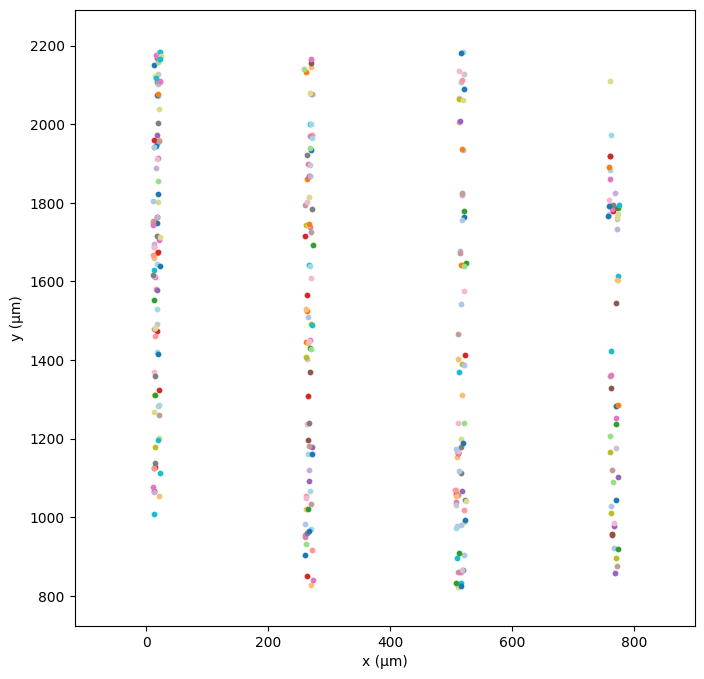

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(ch_pos[:, 0], ch_pos[:, 1], s=25, color='white', marker='s', alpha=0.3)

for cluster_id, unit in units_df.iterrows():
    ax.scatter(unit['x_median'], unit['y_median'], s=10, color=colormap(cluster_id % 20), marker='o')

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_xmargin(0.15)